# Assignment 5 — CIFAR-10 với CNN

**Môn:** Phân tích và Phát triển Hệ thống Thông minh

Thứ tự notebook:

1. Giới thiệu dataset  
2. Load + khảo sát  
3. Tiền xử lý  
4. CNN cơ bản → train → đánh giá  
5. LeNet-like → train → đánh giá  
6. VGG-like → train → đánh giá  
7. ResNet-like → train → đánh giá  
8. So sánh  
9. Kết luận

## 1. Bài toán

CIFAR-10 là bài toán phân loại ảnh màu 10 lớp:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`

Ảnh có kích thước `32 × 32 × 3`.

In [1]:
from pathlib import Path
import time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
RESULT_DIR = PROJECT_DIR / "outputs" / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

PROJECT_DIR: D:\Assignment5\Assignment5_CNN_Project
TensorFlow: 2.21.0
GPU: []


## 2. Load và khảo sát CIFAR-10

In [2]:
CIFAR_DIR = DATA_DIR / "cifar10"
TRAIN_DIR = CIFAR_DIR / "train"
TEST_DIR = CIFAR_DIR / "test"

assert TRAIN_DIR.exists(), f"Không tìm thấy {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Không tìm thấy {TEST_DIR}"

IMG_SIZE = (32, 32)
BATCH_SIZE = 128

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

CLASS_NAMES = train_ds_raw.class_names
print("Classes:", CLASS_NAMES)

Found 50000 files belonging to 10 classes.
Using 40000 files for training.
Found 50000 files belonging to 10 classes.
Using 10000 files for validation.
Found 10000 files belonging to 10 classes.
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


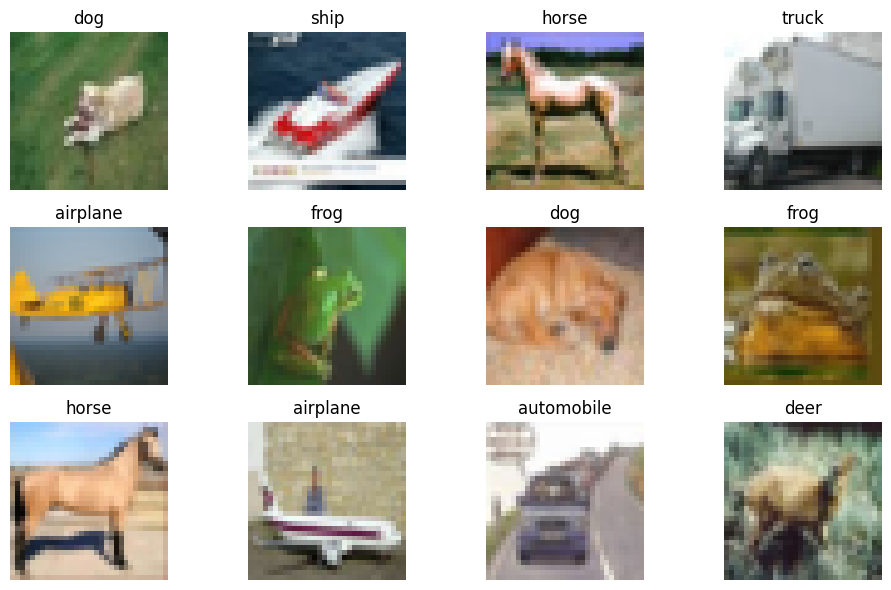

In [3]:
images, labels = next(iter(train_ds_raw))

plt.figure(figsize=(10, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(CLASS_NAMES[int(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Tiền xử lý

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def normalize_image(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = train_ds_raw.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds_raw.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_ds_raw.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

y_test = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
print("Số ảnh test:", len(y_test))

Số ảnh test: 10000


In [5]:
def plot_history(history, dataset_name, model_name):
    h = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(h["accuracy"], label="Train")
    plt.plot(h["val_accuracy"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{dataset_name} - {model_name} - Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{dataset_name}_{model_name}_accuracy.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(h["loss"], label="Train")
    plt.plot(h["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{dataset_name} - {model_name} - Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{dataset_name}_{model_name}_loss.png", dpi=150)
    plt.show()


def evaluate_multiclass(model, X_or_ds, y_true, dataset_name, model_name, class_names):
    probs = model.predict(X_or_ds, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    row = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "params": int(model.count_params()),
    }

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{dataset_name} - {model_name}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{dataset_name}_{model_name}_confusion_matrix.png", dpi=150)
    plt.show()

    return row

## 4. CNN cơ bản

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.2842 - loss: 1.8633 - val_accuracy: 0.3630 - val_loss: 1.6762
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.3884 - loss: 1.6307 - val_accuracy: 0.4241 - val_loss: 1.5433
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.4417 - loss: 1.5065 - val_accuracy: 0.4578 - val_loss: 1.4847
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.4941 - loss: 1.3904 - val_accuracy: 0.5171 - val_loss: 1.3219
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.5218 - loss: 1.3079 - val_accuracy: 0.5178 - val_loss: 1.2934


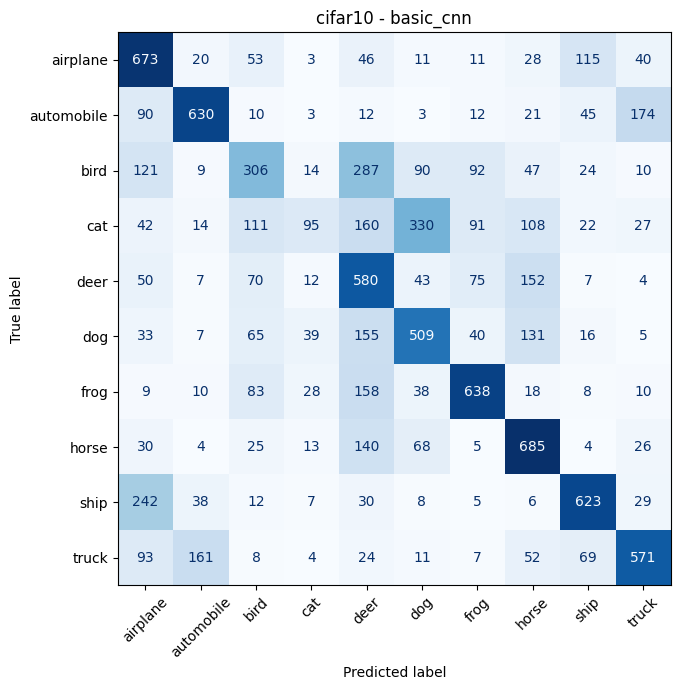

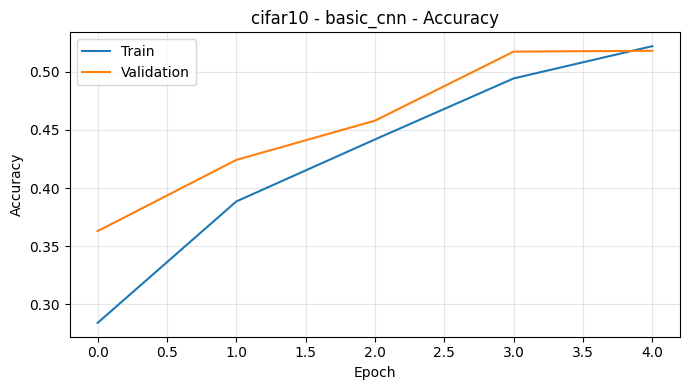

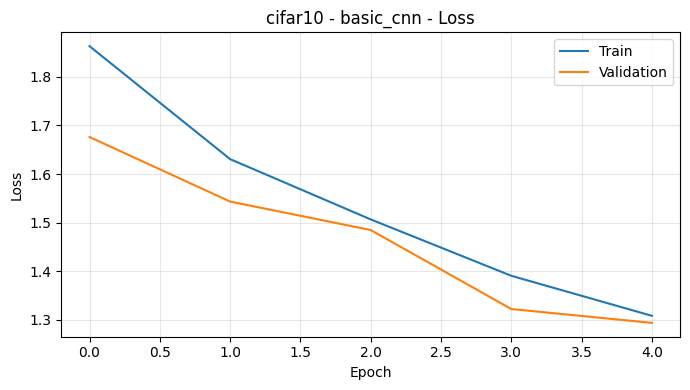

In [6]:
def build_basic_cifar():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

results = []
EPOCHS = 5

model = build_basic_cifar()
model.summary()

start = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(test_ds, verbose=0)
row = evaluate_multiclass(model, test_ds, y_test, "cifar10", "basic_cnn", CLASS_NAMES)
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "cifar10", "basic_cnn")
model.save(MODEL_DIR / "cifar10_basic_cnn.keras")

## 5. Mô hình cải tiến 1 — LeNet-like

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 6)           │             456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 5, 5, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3414 - loss: 1.8563 - val_accuracy: 0.3564 - val_loss: 1.8243
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.3993 - loss: 1.7049 - val_accuracy: 0.4040 - val_loss: 1.6858
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.4372 - loss: 1.5938 - val_accuracy: 0.4408 - val_loss: 1.5755
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.4674 - loss: 1.5009 - val_accuracy: 0.4587 - val_loss: 1.5080
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.4930 - loss: 1.4279 - val_accuracy: 0.4872 - val_loss: 1.4535


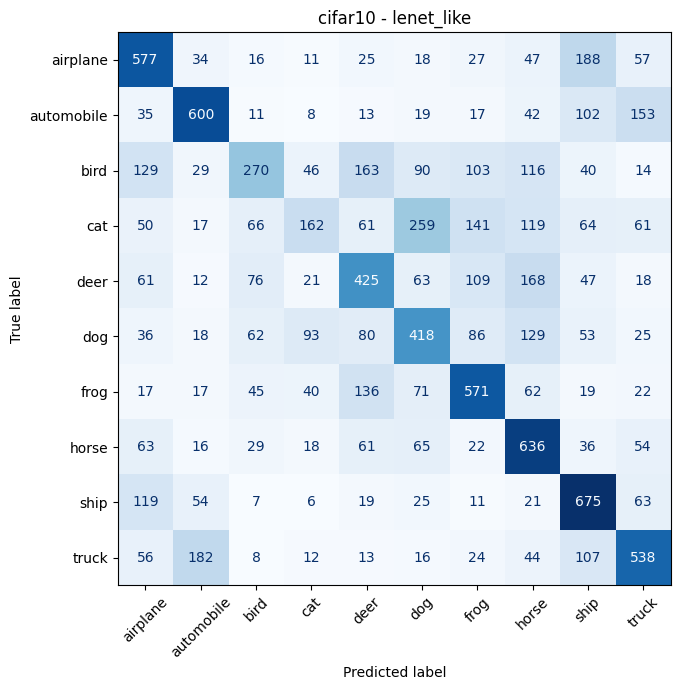

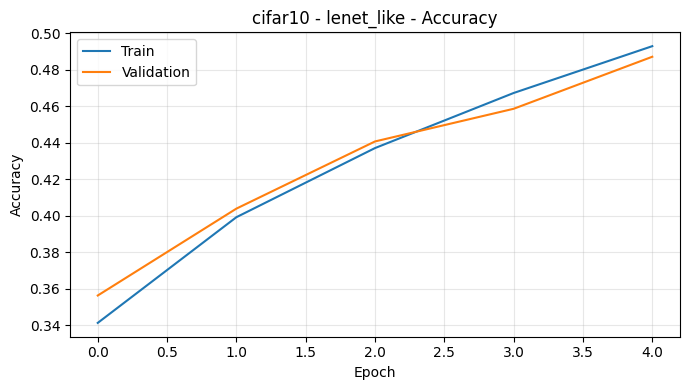

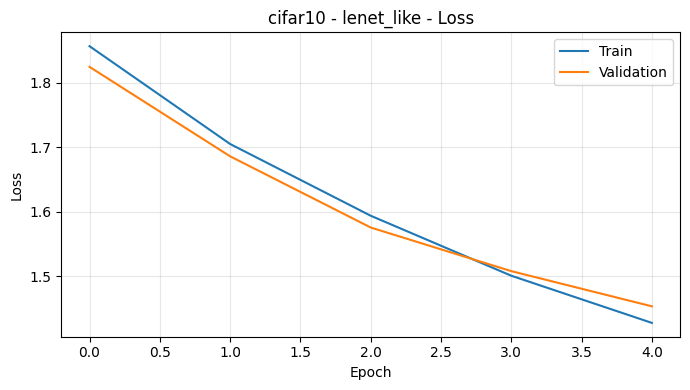

In [7]:
def build_lenet_cifar():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(6, 5, activation="tanh"),
        layers.AveragePooling2D(2),
        layers.Conv2D(16, 5, activation="tanh"),
        layers.AveragePooling2D(2),
        layers.Flatten(),
        layers.Dense(120, activation="tanh"),
        layers.Dense(84, activation="tanh"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_lenet_cifar()
model.summary()

start = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(test_ds, verbose=0)
row = evaluate_multiclass(model, test_ds, y_test, "cifar10", "lenet_like", CLASS_NAMES)
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "cifar10", "lenet_like")
model.save(MODEL_DIR / "cifar10_lenet_like.keras")

## 6. Mô hình cải tiến 2 — VGG-like

Model: "vgg_like"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 304,810 (1.16 MB)

 Trainable params: 304,810 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - accuracy: 0.2233 - loss: 1.9563 - val_accuracy: 0.3534 - val_loss: 1.6875
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 129ms/step - accuracy: 0.3951 - loss: 1.5922 - val_accuracy: 0.4801 - val_loss: 1.3805
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.5101 - loss: 1.3321 - val_accuracy: 0.5503 - val_loss: 1.1876
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.5742 - loss: 1.1697 - val_accuracy: 0.6084 - val_loss: 1.0586
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 174ms/step - accuracy: 0.6193 - loss: 1.0613 - val_accuracy: 0.6335 - val_loss: 1.0041


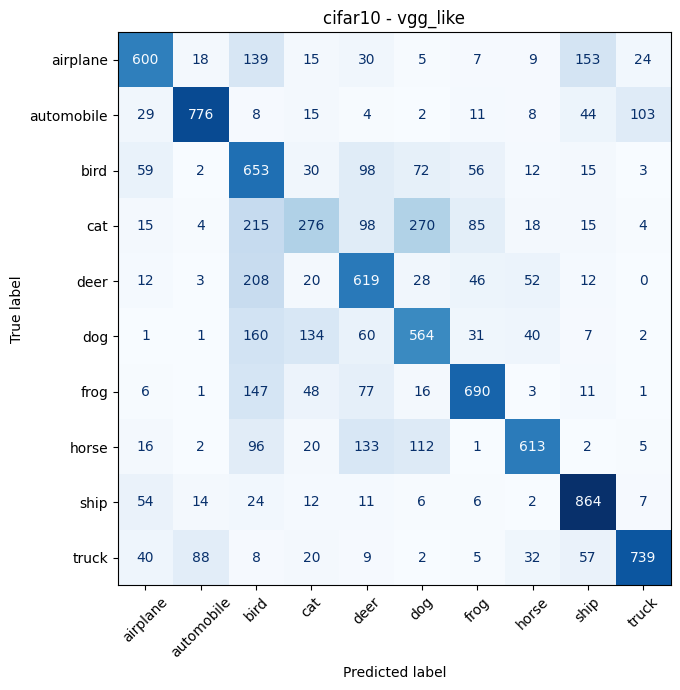

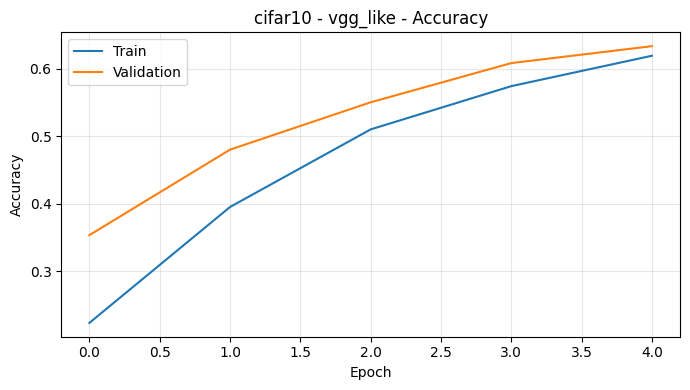

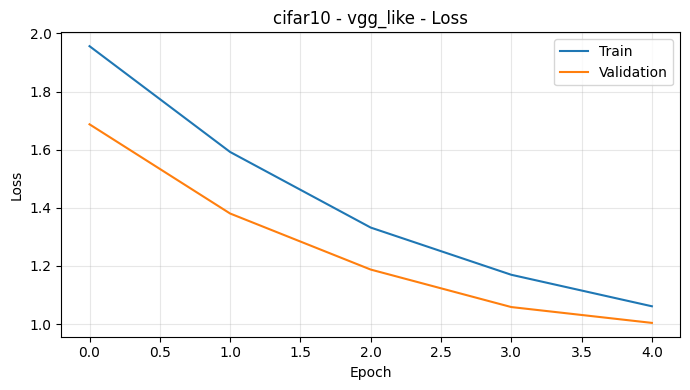

In [8]:
def build_vgg_cifar():
    inputs = keras.Input(shape=(32, 32, 3))

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="vgg_like")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_vgg_cifar()
model.summary()

start = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(test_ds, verbose=0)
row = evaluate_multiclass(model, test_ds, y_test, "cifar10", "vgg_like", CLASS_NAMES)
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "cifar10", "vgg_like")
model.save(MODEL_DIR / "cifar10_vgg_like.keras")

## 7. Mô hình cải tiến 3 — ResNet-like

Model: "resnet_like"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 32, 32, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_11 (Conv2D)            │ (None, 32, 32, 32)        │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 32, 32, 32)        │             128 │ conv2d_11[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu (ReLU)                  │ (None, 32, 32, 32)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_12 (Conv2D)            │ (None, 32, 32, 32)        │           9,216 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 32, 32, 32)        │             128 │ conv2d_12[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_1 (ReLU)                │ (None, 32, 32, 32)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_13 (Conv2D)            │ (None, 32, 32, 32)        │           9,216 │ re_lu_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 32, 32, 32)        │             128 │ conv2d_13[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 32, 32, 32)        │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 32, 32, 32)        │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_14 (Conv2D)            │ (None, 16, 16, 64)        │          18,432 │ re_lu_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 16, 16, 64)        │             256 │ conv2d_14[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_3 (ReLU)                │ (None, 16, 16, 64)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_15 (Conv2D)            │ (None, 16, 16, 64)        │          36,86

 Total params: 384,234 (1.47 MB)

 Trainable params: 382,634 (1.46 MB)

 Non-trainable params: 1,600 (6.25 KB)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 197s 539ms/step - accuracy: 0.5129 - loss: 1.3431 - val_accuracy: 0.2373 - val_loss: 2.7945
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 475ms/step - accuracy: 0.6618 - loss: 0.9467 - val_accuracy: 0.5592 - val_loss: 1.2279
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 135s 431ms/step - accuracy: 0.7283 - loss: 0.7757 - val_accuracy: 0.6270 - val_loss: 1.0585
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 231ms/step - accuracy: 0.7693 - loss: 0.6618 - val_accuracy: 0.6380 - val_loss: 1.0643
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - accuracy: 0.8018 - loss: 0.5704 - val_accuracy: 0.7011 - val_loss: 0.8473


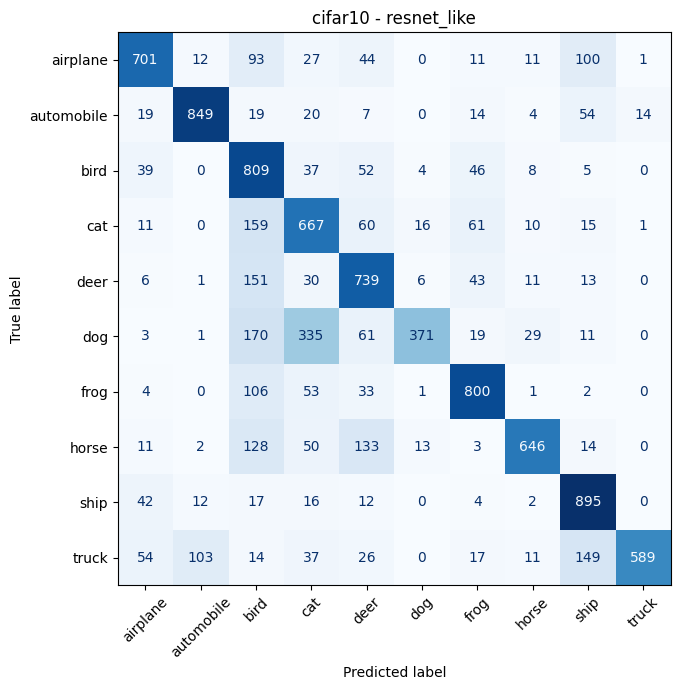

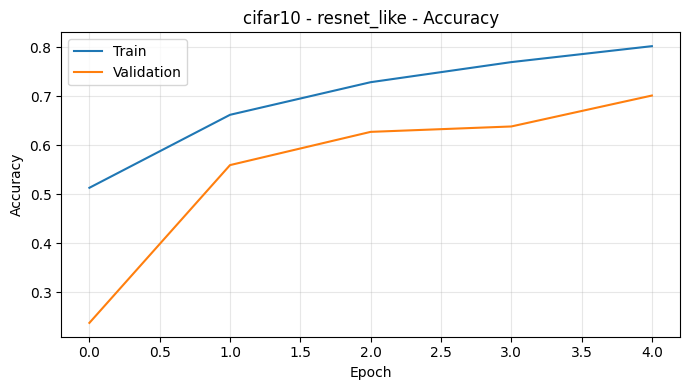

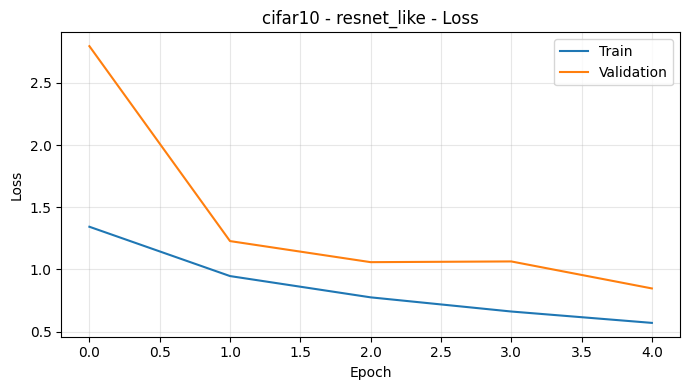

In [9]:
def residual_block(x, filters, downsample=False):
    stride = 2 if downsample else 1
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)

def build_resnet_cifar():
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)
    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="resnet_like")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_resnet_cifar()
model.summary()

start = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(test_ds, verbose=0)
row = evaluate_multiclass(model, test_ds, y_test, "cifar10", "resnet_like", CLASS_NAMES)
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "cifar10", "resnet_like")
model.save(MODEL_DIR / "cifar10_resnet_like.keras")

## 8. So sánh kết quả

,dataset,model,accuracy,precision_macro,recall_macro,f1_macro,params,loss,train_seconds
3,cifar10,resnet_like,0.7066,0.755202,0.7066,0.706643,384234,0.834277,622.675809
2,cifar10,vgg_like,0.6394,0.658057,0.6394,0.640127,304810,1.003265,216.628658
0,cifar10,basic_cnn,0.5310,0.536430,0.5310,0.516697,111050,1.276413,78.029191
1,cifar10,lenet_like,0.4872,0.480684,0.4872,0.473833,62006,1.438743,49.645723


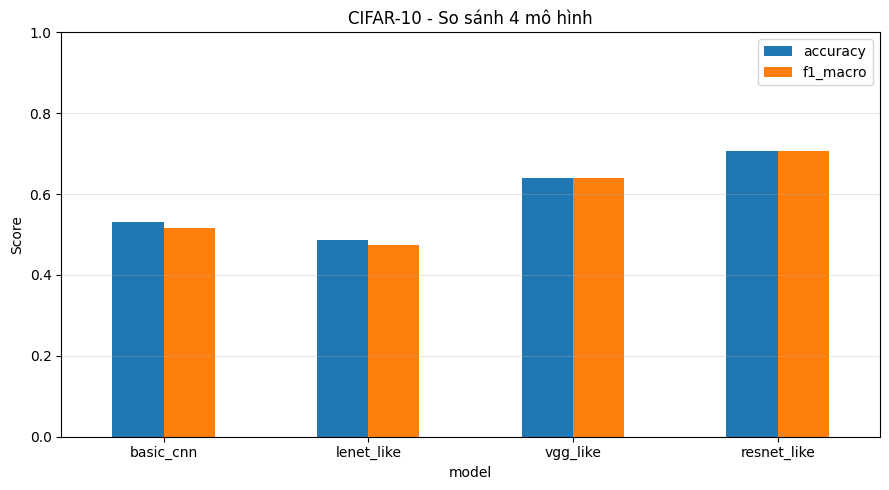

In [10]:
results_df = pd.DataFrame(results)
display(results_df.sort_values("accuracy", ascending=False))

results_df.to_csv(RESULT_DIR / "cifar10_results.csv", index=False)

ax = results_df.set_index("model")[["accuracy", "f1_macro"]].plot(
    kind="bar", figsize=(9, 5)
)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("CIFAR-10 - So sánh 4 mô hình")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cifar10_model_comparison.png", dpi=150)
plt.show()

## 9. Kết luận

CIFAR-10 phức tạp hơn Fashion-MNIST vì là ảnh màu và đối tượng đa dạng hơn.  
Sau khi chạy, so sánh **Accuracy, Macro-F1, Loss, số tham số và thời gian train** để đưa ra nhận xét dựa trên kết quả thực tế.